In [1]:
# Install datasets Library (if not already installed)
# !pip install datasets

# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleaning
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

ModuleNotFoundError: No module named 'datasets'

Bar Chart - Count of Job Postings

In [ ]:
job_count = df['job_title_short'].value_counts() .head(6)
job_count = job_count.sort_values(ascending=False)
job_count

,count
job_title_short,
Data Analyst,196075
Data Engineer,186241
Data Scientist,172286
Business Analyst,49063
Software Engineer,44929
Senior Data Engineer,44563


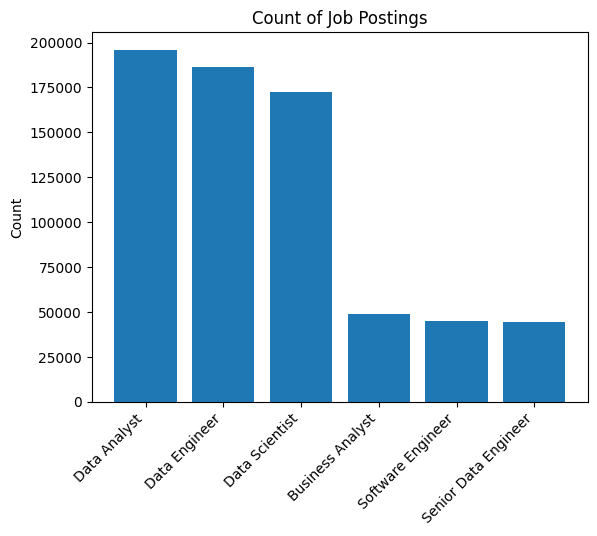

In [ ]:
plt.bar(job_count.index, job_count.values)
plt.title('Count of Job Postings')
plt.xticks(rotation=45, ha = 'right')
plt.ylabel('Count')
plt.show()

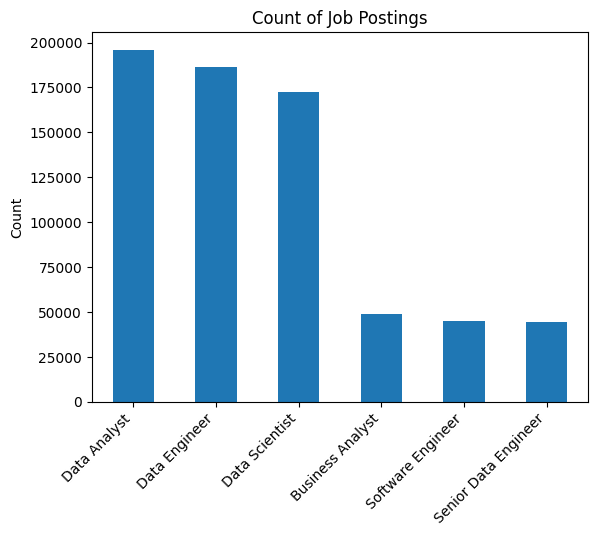

In [ ]:
job_count.plot(kind='bar')
plt.ylabel('Count')
plt.xlabel("")
plt.title('Count of Job Postings')
plt.xticks(rotation=45, ha = 'right')
plt.show()

<Axes: ylabel='job_title_short'>

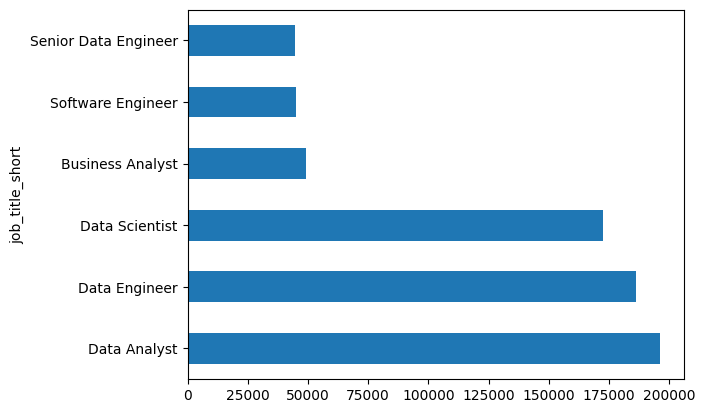

In [ ]:
job_count.plot(kind='barh')

In [ ]:
df[['job_posted_date', 'salary_year_avg']].dropna(subset=['salary_year_avg'])

,job_posted_date,salary_year_avg
28,2023-08-01 13:37:57,109500.0
77,2023-06-26 14:22:54,140000.0
92,2023-02-21 13:29:59,120000.0
100,2023-07-31 13:01:18,228222.0
109,2023-10-12 13:02:19,89000.0
...,...,...
785624,2023-08-31 06:02:16,139216.0
785641,2023-01-04 16:36:07,150000.0
785648,2023-04-12 06:02:51,221875.0
785682,2023-03-04 06:16:08,157500.0


<Axes: xlabel='job_posted_date'>

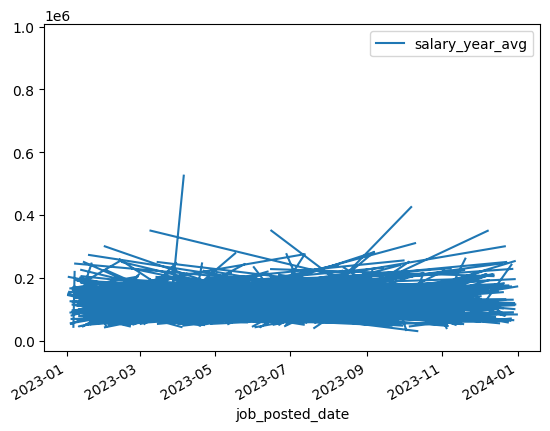

In [ ]:
df.plot(x = 'job_posted_date', y = 'salary_year_avg', kind='line')

In [ ]:
job_posted_month = df.groupby(df['job_posted_date'].dt.month)['salary_year_avg'].mean()

df_cleaned = df[['job_posted_date', 'salary_year_avg']].dropna(subset=['salary_year_avg'])
df_cleaned['month'] = df_cleaned['job_posted_date'].dt.month
df_cleaned['mean_monthly_salary'] = df_cleaned['month'].map(job_posted_month)

df_sorted = df_cleaned.sort_values(by=['mean_monthly_salary', 'job_posted_date'], ascending=True)
df_sorted

,job_posted_date,salary_year_avg,month,mean_monthly_salary
98605,2023-11-01 00:09:34,170575.0,11,119817.184014
775462,2023-11-01 01:00:46,136793.0,11,119817.184014
711510,2023-11-01 02:09:13,79200.0,11,119817.184014
701138,2023-11-01 03:09:36,170575.0,11,119817.184014
702031,2023-11-01 03:54:45,136875.0,11,119817.184014
...,...,...,...,...
361426,2023-08-31 23:03:22,105000.0,8,125819.429100
358685,2023-08-31 23:03:53,120000.0,8,125819.429100
366428,2023-08-31 23:09:31,146500.0,8,125819.429100
214733,2023-08-31 23:30:41,130316.0,8,125819.429100


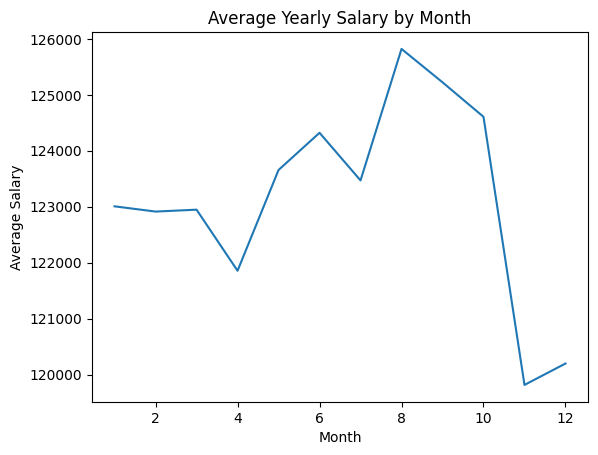

In [ ]:
job_posted_month.plot(kind='line')
plt.ylabel('Average Salary')
plt.xlabel('Month')
plt.title('Average Yearly Salary by Month')
plt.xticks(rotation=0)
plt.show()

***Visualize*** ***Salaries***
Median Salary  Vs data Science

In [ ]:
job_salary = df.groupby('job_title_short')['salary_year_avg'].median().sort_values()

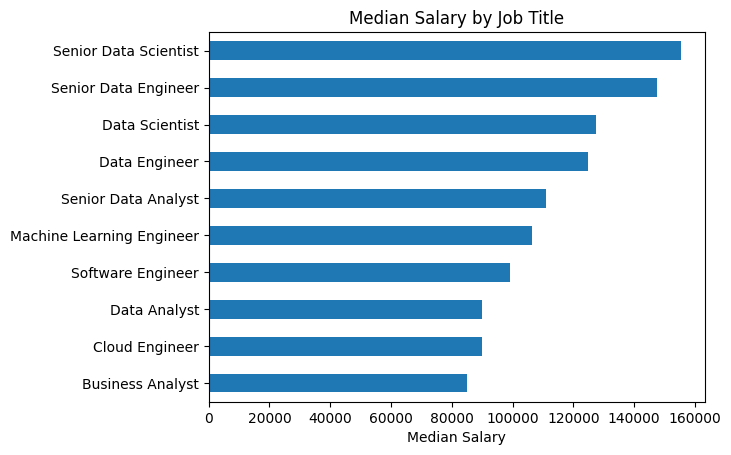

In [ ]:
job_salary.plot(kind='barh')
plt.xlabel('Median Salary')
plt.ylabel('')
plt.title('Median Salary by Job Title')
plt.show()